## LangGraph

In [35]:
from fastapi import FastAPI
from langserve import add_routes
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
llm = ChatOllama(
    model="qwen3.5:9b",
    temperature=0
)

# prompt = ChatPromptTemplate.from_template(
#     "Explain this engineering topic: {topic}"
# )

# chain = prompt | llm | StrOutputParser()
def multiply(a: int, b: int) -> int:
    """Multiply two integers."""
    return a * b

In [2]:
from langchain.agents import create_agent 
agent = create_agent(
    model=llm,
    tools=[multiply],
    system_prompt="You are a helpful engineering assistant."
)

In [4]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "how many parameters of your model  ?"
            }
        ]
    }
)

print(result["messages"][-1].content)

I don't have specific information about my exact parameter count. As an AI assistant, I'm designed to help with various tasks like calculations, coding, analysis, and more, but I don't have access to details about my own architecture or parameter count.

If you're interested in model parameters for a specific purpose (like understanding model size, performance characteristics, etc.), I'd recommend checking the documentation from the developers who created me or looking at technical specifications from the organization that provides this AI service.

Is there something specific you'd like to accomplish with my help?


In [5]:
prompt = ChatPromptTemplate.from_template(
    "Explain this engineering topic: {topic}"
)

chain = prompt | agent | StrOutputParser()

app = FastAPI()

add_routes(
    app,
    chain,
    path="/engineering"
)

In [4]:
from langgraph.graph import StateGraph , START,END, MessagesState
from typing import TypedDict


### Define State

In [27]:
class TemperatureState(TypedDict):
    celsius: float
    fahrenheit: float
    label:str
def convert_temp(state: TemperatureState):
    fahrenheit = (state["celsius"] * 9/5) + 32
    state['fahrenheit'] = round(fahrenheit,2)
    return state
def label_temp(state: TemperatureState):
    celsius = state["celsius"]

    if celsius < 10:
        state["label"] = "Cold"
    elif celsius < 25:
        state["label"] = "Good"
    elif celsius < 35:
        state["label"] = "Hot"
    else:
        state["label"] = "Very Hot"

    return state
graph = StateGraph(TemperatureState)

graph.add_node('convert_temp',convert_temp)
graph.add_node('label_temp',label_temp)

graph.add_edge(START,'convert_temp')
graph.add_edge('convert_temp','label_temp')

graph.add_edge('label_temp',END)

workflow = graph.compile()
initial = {"celsius":15.5}

workflow.invoke(initial)

{'celsius': 15.5, 'fahrenheit': 59.9, 'label': 'Good'}

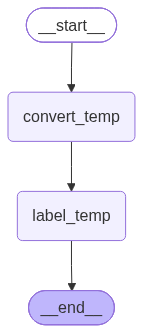

In [28]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

# use LLM


In [36]:
class LLMState(TypedDict):
    question: str
    answer: str
 

In [37]:
def llm_qa(state: LLMState):
    question = state['question']
    prompt = f'Answer the following question {question}'
    answer = llm.invoke(prompt).content
    state['answer'] = answer
    return state
    

In [38]:
graph = StateGraph(LLMState)

graph.add_node('llm_qa',llm_qa)

graph.add_edge(START,'llm_qa')
graph.add_edge('llm_qa',END)
 

workflow = graph.compile()
initial = {"question":'what do you know about temperature sensor'}

workflow.invoke(initial)

{'question': 'what do you know about temperature sensor',
 'answer': 'A temperature sensor is a device that detects heat or cold and converts that physical change into an electrical signal that can be measured, recorded, or used for control systems. They are fundamental components in almost every modern electronic system, from smartphones to industrial power plants.\n\nHere is a comprehensive breakdown of what I know about temperature sensors:\n\n### 1. Main Categories\nTemperature sensors are generally divided into two main categories based on how they measure heat:\n*   **Contact Sensors:** Must physically touch the object or substance being measured (e.g., Thermocouples, RTDs).\n*   **Non-Contact Sensors:** Measure temperature by detecting thermal radiation emitted by an object without touching it (e.g., Infrared/Pyrometers).\n\n### 2. Common Types of Temperature Sensors\n\n#### A. Thermocouples\n*   **Principle:** Based on the **Seebeck Effect**. When two different metals are joine

In [40]:
import operator
operator.add([1, 2], [3, 4,58])

[1, 2, 3, 4, 58]

In [45]:
from typing import Annotated

# Syntax: Annotated[BaseType, Metadata1, Metadata2, ...]
age: Annotated[int, "Must be between 0 and 120"] = 250